In [1]:
from google.colab import files
uploaded = files.upload()

Saving Tata_Power_final_2025.xlsx to Tata_Power_final_2025.xlsx


In [2]:
!pip install econml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from econml.dml import CausalForestDML

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 114.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 76.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.9/151.9 kB 16.4 MB/s eta 0:00:00
  Attempting uninstall: shap
    Found existing installation: shap 0.51.0
    Uninstalling shap-0.51.0:
      Successfully uninstalled shap-0.51.0


In [3]:
df = pd.read_excel("Tata_Power_final_2025.xlsx")

df.head()

,datetime,wdLoad,temp,rh
0,2025-01-01 00:00:00,276.186445,24.733333,78.066667
1,2025-01-01 00:15:00,279.700694,24.766667,78.133333
2,2025-01-01 00:30:00,283.051573,24.766667,78.133333
3,2025-01-01 00:45:00,286.960382,24.666667,78.333333
4,2025-01-01 01:00:00,292.949629,24.600000,78.633333


In [4]:
# Drop unnecessary ID columns if present
df = df.drop(columns=[col for col in df.columns if '_id' in col], errors='ignore')

df['datetime'] = pd.to_datetime(df['datetime'])
df = df.sort_values('datetime')
df['hour'] = df['datetime'].dt.hour
df['dayofweek'] = df['datetime'].dt.dayofweek

df = df.dropna()

df.head()

,datetime,wdLoad,temp,rh,hour,dayofweek
0,2025-01-01 00:00:00,276.186445,24.733333,78.066667,0,2
1,2025-01-01 00:15:00,279.700694,24.766667,78.133333,0,2
2,2025-01-01 00:30:00,283.051573,24.766667,78.133333,0,2
3,2025-01-01 00:45:00,286.960382,24.666667,78.333333,0,2
4,2025-01-01 01:00:00,292.949629,24.600000,78.633333,1,2


In [5]:
print(df.columns)

Index(['datetime', 'wdLoad', 'temp', 'rh', 'hour', 'dayofweek'], dtype='object')


In [6]:
TEMP + RH AS TREATMENT

SyntaxError: invalid syntax (2855502858.py, line 1)

In [7]:
Y = df['wdLoad'].values
T = df[['temp', 'rh']].values
X = df[['hour']].values

In [8]:
model = CausalForestDML(
    n_estimators=100,
    min_samples_leaf=10,
    random_state=42
)

model.fit(Y, T, X=X)

In [9]:
effects = model.const_marginal_effect(X)

print("Effects shape:", effects.shape)

Effects shape: (35040, 2)


In [10]:
ate_temp = np.mean(effects[:,0])
ate_rh = np.mean(effects[:,1])

print("ATE (Temperature):", ate_temp)
print("ATE (Humidity):", ate_rh)

ATE (Temperature): 9.449476365882997
ATE (Humidity): 0.9869790650930288


In [11]:
df_effect = pd.DataFrame()
df_effect['hour'] = df['hour']
df_effect['temp_effect'] = effects[:,0]
df_effect['rh_effect'] = effects[:,1]

print(df_effect.groupby('hour')['temp_effect'].mean())
print(df_effect.groupby('hour')['rh_effect'].mean())

hour
0      4.987637
1      4.260137
2      6.757410
3      8.493572
4      9.887410
5     10.178300
6      9.847959
7     11.269152
8     13.163203
9     14.596273
10    14.550466
11    12.382795
12     9.595331
13     8.792392
14     8.409860
15     7.821397
16     8.774616
17    10.328825
18    11.133306
19    10.197022
20     9.212722
21     8.110621
22     7.473683
23     6.563343
Name: temp_effect, dtype: float64
hour
0     0.337371
1     0.489177
2     0.511900
3     1.031467
4     1.450896
5     1.683204
6     1.717177
7     1.882203
8     2.103550
9     2.219645
10    1.968602
11    1.538815
12    1.040093
13    0.855173
14    0.866702
15    0.747130
16    0.682328
17    0.586823
18    0.504059
19    0.373310
20    0.280230
21    0.287003
22    0.252070
23    0.278570
Name: rh_effect, dtype: float64


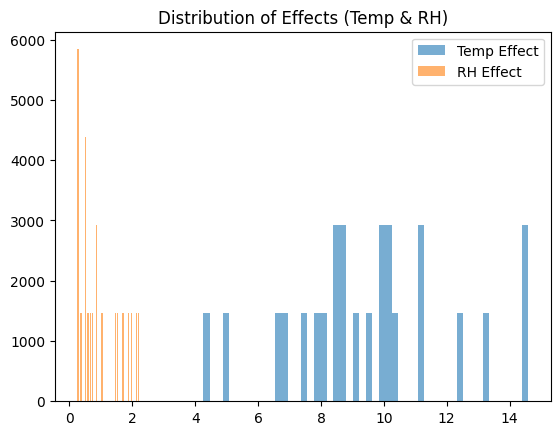

In [12]:
plt.hist(effects[:,0], bins=50, alpha=0.6, label='Temp Effect')
plt.hist(effects[:,1], bins=50, alpha=0.6, label='RH Effect')
plt.legend()
plt.title("Distribution of Effects (Temp & RH)")
plt.show()

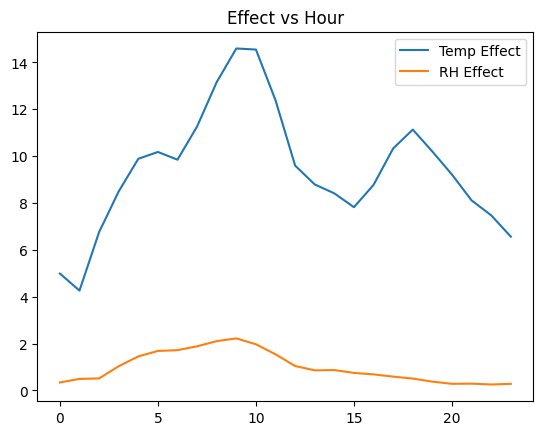

In [13]:
temp_by_hour = df_effect.groupby('hour')['temp_effect'].mean()
rh_by_hour = df_effect.groupby('hour')['rh_effect'].mean()

plt.plot(temp_by_hour.index, temp_by_hour.values, label='Temp Effect')
plt.plot(rh_by_hour.index, rh_by_hour.values, label='RH Effect')
plt.legend()
plt.title("Effect vs Hour")
plt.show()

In [ ]:
TEMP AS TREATMENT

In [14]:
Y = df['wdLoad'].values
T_temp = df['temp'].values
X_temp = df[['hour', 'rh']].values

In [15]:
model_temp = CausalForestDML(
    n_estimators=100,
    min_samples_leaf=10,
    random_state=42
)

model_temp.fit(Y, T_temp, X=X_temp)

In [16]:
effects_temp = model_temp.effect(X_temp)

In [17]:
ate_temp = np.mean(effects_temp)
print("ATE (Temperature):", ate_temp)

ATE (Temperature): 8.546390978801881


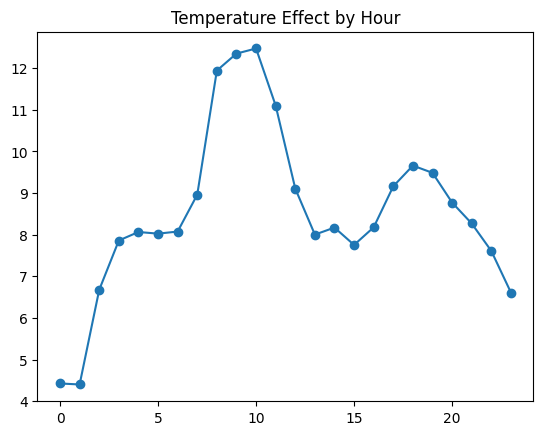

In [18]:
df_temp = pd.DataFrame()
df_temp['hour'] = df['hour']
df_temp['effect'] = effects_temp

temp_by_hour = df_temp.groupby('hour')['effect'].mean()

plt.plot(temp_by_hour.index, temp_by_hour.values, marker='o')
plt.title("Temperature Effect by Hour")
plt.show()

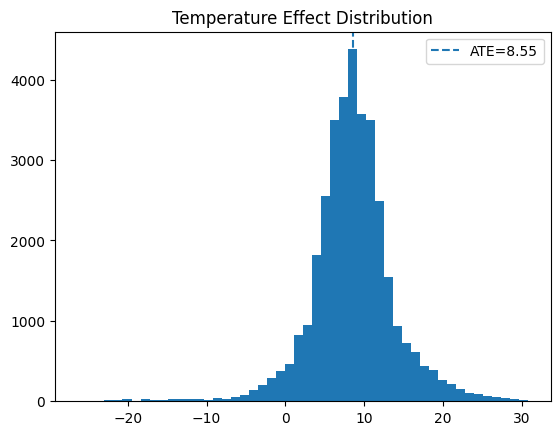

In [19]:
plt.hist(effects_temp, bins=50)
plt.axvline(ate_temp, linestyle='--', label=f'ATE={ate_temp:.2f}')
plt.legend()
plt.title("Temperature Effect Distribution")
plt.show()

In [ ]:
RH AS TREATMENT

In [20]:
T_rh = df['rh'].values
X_rh = df[['hour', 'temp']].values

In [21]:
model_rh = CausalForestDML(
    n_estimators=100,
    min_samples_leaf=10,
    random_state=42
)

model_rh.fit(Y, T_rh, X=X_rh)

In [22]:
effects_rh = model_rh.effect(X_rh)

In [23]:
ate_rh = np.mean(effects_rh)
print("ATE (Humidity):", ate_rh)

ATE (Humidity): 0.9879505667304641


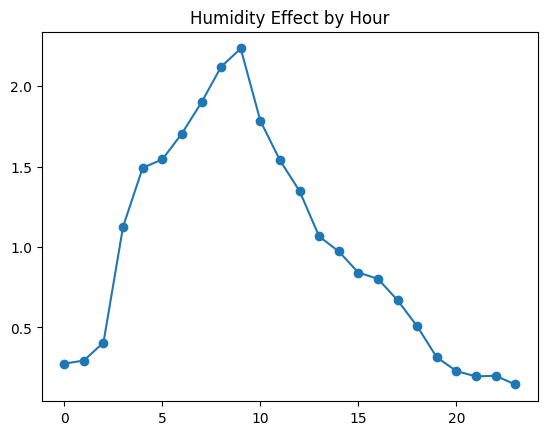

In [24]:
df_rh = pd.DataFrame()
df_rh['hour'] = df['hour']
df_rh['effect'] = effects_rh

rh_by_hour = df_rh.groupby('hour')['effect'].mean()

plt.plot(rh_by_hour.index, rh_by_hour.values, marker='o')
plt.title("Humidity Effect by Hour")
plt.show()

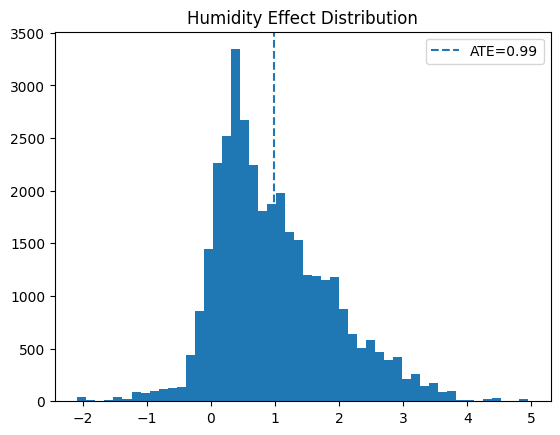

In [25]:
plt.hist(effects_rh, bins=50)
plt.axvline(ate_rh, linestyle='--', label=f'ATE={ate_rh:.2f}')
plt.legend()
plt.title("Humidity Effect Distribution")
plt.show()